## Objective

Analyze hotel booking data to identify factors driving cancellations and revenue loss, build a model to predict cancellations, and provide actionable recommendations to improve profitability.

In [1]:
import pandas as pd

df = pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [5]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [6]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [7]:
# Cleaning missing values to prepare for analysis and modeling
# Dropping high-missing column, filling others with reasonable defaults

df = df.drop(columns=['company'])

df['agent'] = df['agent'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['children'] = df['children'].fillna(0)

In [8]:
# Checking cancellation distribution (target variable)
df['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

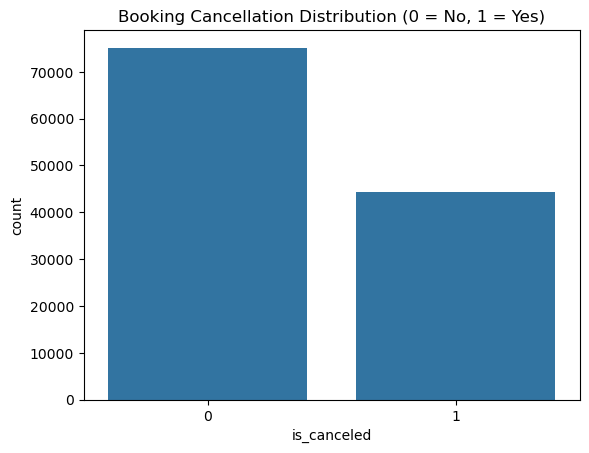

In [9]:
# 37% is high... Visualizing cancellation distribution for clear stakeholder communication
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='is_canceled', data=df)
plt.title('Booking Cancellation Distribution (0 = No, 1 = Yes)')
plt.show()

high cancellations usually come from:

Long lead times (people book early → change plans)
No deposit bookings (easy to cancel, no penalty)
Certain market segments (online/agents = less committed)
Price sensitivity (people rebook cheaper options)

Let's figure out why

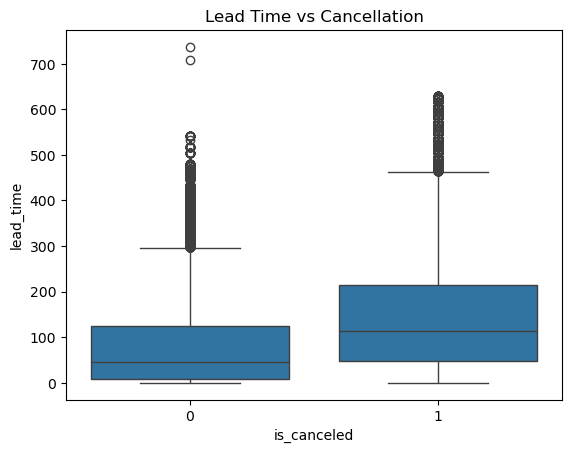

In [10]:
# Analyzing if longer lead times increase cancellation likelihood
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Lead Time vs Cancellation')
plt.show()

In [11]:
# Comparing average lead time for canceled vs not canceled bookings
df.groupby('is_canceled')['lead_time'].mean()

is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64

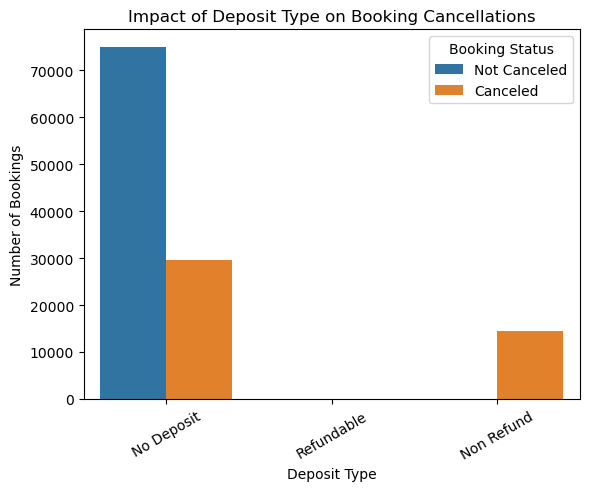

In [13]:
df['cancellation_status'] = df['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})

sns.countplot(x='deposit_type', hue='cancellation_status', data=df)
plt.title('Impact of Deposit Type on Booking Cancellations')
plt.xlabel('Deposit Type')
plt.ylabel('Number of Bookings')
plt.legend(title='Booking Status')
plt.xticks(rotation=30)
plt.show()

<h3>Insight: Deposit Type vs Cancellations</h3>

<p>
Bookings with <b>"No Deposit"</b> have a 
<span style="color:red; font-weight:bold;">significantly higher number of cancellations</span>, 
indicating lower customer commitment. In contrast, <b>"Non Refund"</b> bookings show very few cancellations, 
suggesting that stricter deposit policies can help reduce cancellation risk and protect revenue.
</p>

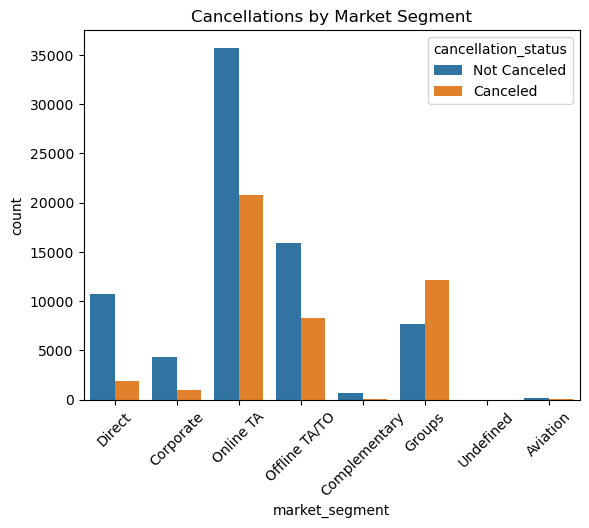

In [15]:
# Analyzing which customer segments drive the most cancellations
sns.countplot(x='market_segment', hue='cancellation_status', data=df)
plt.title('Cancellations by Market Segment')
plt.xticks(rotation=45)
plt.show()

<h3>Insight: Market Segment vs Cancellations</h3>

<p>
The <b>Online TA</b> segment drives the highest volume of bookings, but also contributes a 
<span style="color:red; font-weight:bold;">significant number of cancellations</span>, indicating a major source of revenue risk.
Additionally, the <b>Groups</b> segment shows a disproportionately high number of cancellations relative to completed bookings, suggesting lower reliability.
</p>

<h4>Analyst Thought Process</h4>
<ul>
  <li>Are high-volume segments (e.g., Online TA) also the highest risk?</li>
  <li>Which segments have the highest <b>cancellation rate</b>, not just volume?</li>
  <li>Are certain segments more price-sensitive or less committed?</li>
</ul>

<h4>Next Steps (Deeper Analysis)</h4>
<ul>
  <li>Calculate <b>cancellation rate by market segment</b> to identify highest-risk customers</li>
  <li>Analyze <b>revenue impact (ADR)</b> by segment to prioritize high-value segments</li>
  <li>Combine with <b>deposit type + lead time</b> to understand behavior patterns</li>
</ul>

<h4>Business Recommendations</h4>
<ul>
  <li>Introduce stricter deposit policies for high-risk segments (e.g., Online TA, Groups)</li>
  <li>Offer incentives for low-risk segments (e.g., Corporate, Direct) to increase bookings</li>
  <li>Develop targeted strategies to reduce cancellations in high-volume channels</li>
</ul>

<h4>Shareholder Value</h4>
<p>
Focusing on high-risk, high-volume segments allows the business to 
<span style="color:green; font-weight:bold;">reduce cancellations at scale</span>, directly improving revenue stability and forecasting accuracy.
</p>

In [17]:
# Calculating cancellation rate by market segment to identify the riskiest customer channels
segment_cancel_rate = (
    df.groupby('market_segment')['is_canceled']
      .mean()
      .sort_values(ascending=False)
)

segment_cancel_rate

market_segment
Undefined        1.000000
Groups           0.610620
Online TA        0.367211
Offline TA/TO    0.343160
Aviation         0.219409
Corporate        0.187347
Direct           0.153419
Complementary    0.130552
Name: is_canceled, dtype: float64

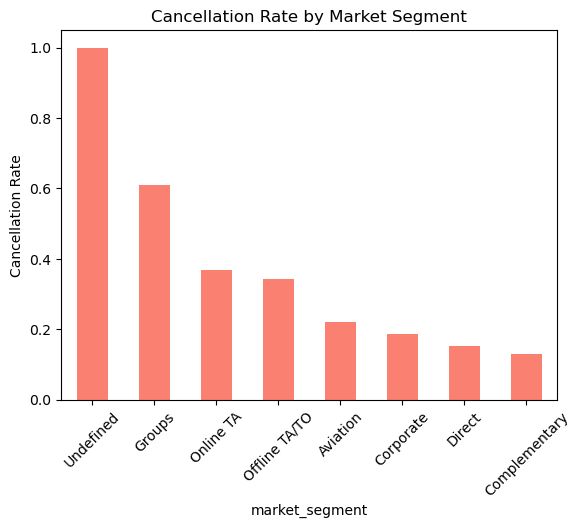

In [18]:
# Visualizing cancellation rate by market segment (stakeholder-friendly)
segment_cancel_rate.plot(kind='bar', color='salmon')
plt.title('Cancellation Rate by Market Segment')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45)
plt.show()

In [19]:
# Analyzing average revenue (ADR) by market segment to find high-value customers
segment_adr = df.groupby('market_segment')['adr'].mean().sort_values(ascending=False)
segment_adr

market_segment
Online TA        117.197063
Direct           115.445175
Aviation         100.142110
Offline TA/TO     87.354783
Groups            79.479472
Corporate         69.358952
Undefined         15.000000
Complementary      2.886366
Name: adr, dtype: float64

In [20]:
# Combining cancellation rate + revenue to identify high-risk, high-impact segments
segment_summary = pd.concat([segment_cancel_rate, segment_adr], axis=1)
segment_summary.columns = ['cancellation_rate', 'avg_adr']
segment_summary.sort_values(by='cancellation_rate', ascending=False)

,cancellation_rate,avg_adr
market_segment,,
Undefined,1.000000,15.000000
Groups,0.610620,79.479472
Online TA,0.367211,117.197063
Offline TA/TO,0.343160,87.354783
Aviation,0.219409,100.142110
Corporate,0.187347,69.358952
Direct,0.153419,115.445175
Complementary,0.130552,2.886366


In [23]:
# Checking booking volume by market segment to measure business impact at scale
df['market_segment'].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

In [24]:
# Combining cancellation rate, revenue, and volume into one table
segment_summary = segment_summary.copy()
segment_summary['volume'] = df['market_segment'].value_counts()

segment_summary.sort_values(by='cancellation_rate', ascending=False)

,cancellation_rate,avg_adr,volume
market_segment,,,
Undefined,1.000000,15.000000,2
Groups,0.610620,79.479472,19811
Online TA,0.367211,117.197063,56477
Offline TA/TO,0.343160,87.354783,24219
Aviation,0.219409,100.142110,237
Corporate,0.187347,69.358952,5295
Direct,0.153419,115.445175,12606
Complementary,0.130552,2.886366,743


<h3>Key Insight: High-Risk, High-Impact Segments</h3>

<p>
The <b>Online TA</b> segment represents the <b>largest booking volume</b> and generates 
<span style="color:green; font-weight:bold;">high revenue (ADR)</span>, but also has a 
<span style="color:red; font-weight:bold;">high cancellation rate (~37%)</span>. 
This makes it the <b>biggest driver of revenue loss</b>.
</p>

<p>
The <b>Groups</b> segment has an even 
<span style="color:red; font-weight:bold;">higher cancellation rate (~61%)</span> 
with substantial volume, making it a <b>high-risk segment</b> that requires stricter controls.
</p>

<h3>Business Problem and prediction solution</h3>

<p>
A significant portion of bookings—especially from <b>Online TA</b> and <b>Groups</b>—are 
<span style="color:red; font-weight:bold;">canceled at high rates</span>, leading to 
<span style="color:red; font-weight:bold;">major revenue loss and unreliable forecasting</span>.
</p>

In [27]:
# Estimating total revenue lost from cancellations (baseline problem size)
lost_revenue = df[df['is_canceled'] == 1]['adr'].sum()
lost_revenue

np.float64(4641942.67)

### Over and above. Make a ML model that finds why people cancel vs. dont cancel, then we find how many would cancel if we implement cancellation friction

In [29]:
# Preparing features for ML model (selecting relevant columns + encoding categories)
from sklearn.model_selection import train_test_split

# Select useful features
features = [
    'lead_time', 'adr', 'deposit_type', 'market_segment',
    'customer_type', 'total_of_special_requests'
]

df_model = df[features + ['is_canceled']].copy()

# One-hot encode categorical variables
df_model = pd.get_dummies(df_model, drop_first=True)

# Split data
X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Training a basic classification model to predict cancellations
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86     14907
           1       0.79      0.72      0.75      8971

    accuracy                           0.82     23878
   macro avg       0.81      0.80      0.80     23878
weighted avg       0.82      0.82      0.82     23878



### needs to be better...

In [31]:
# Building a professional ML pipeline with hyperparameter tuning
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Evaluate
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)
print(grid.best_params_)
print(classification_report(y_test, y_pred))

{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}
              precision    recall  f1-score   support

           0       0.83      0.91      0.87     14907
           1       0.83      0.69      0.75      8971

    accuracy                           0.83     23878
   macro avg       0.83      0.80      0.81     23878
weighted avg       0.83      0.83      0.82     23878



In [32]:
# Explaining model + simulating business impact using predictions

import numpy as np

# --- Model Explanation ---
print("MODEL PURPOSE:")
print("This model predicts the likelihood of a booking being canceled based on customer behavior.")
print("It helps identify high-risk bookings so the business can take action (e.g., stricter deposits).\n")

# Feature importance
importances = best_model.named_steps['model'].feature_importances_
feature_names = X.columns

feat_imp = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)[:10]

print("TOP DRIVERS OF CANCELLATIONS:")
for f, i in feat_imp:
    print(f"{f}: {round(i, 3)}")

# --- Business Impact Simulation ---
# Predict probabilities
probs = best_model.predict_proba(X)[:, 1]

df_sim = df.copy()
df_sim['cancel_prob'] = probs

# Assume we intervene on top 20% highest-risk bookings
threshold = np.percentile(probs, 80)
high_risk = df_sim['cancel_prob'] >= threshold

# Assume intervention reduces cancellations by 30% in this group
impact_mask = (high_risk) & (df_sim['is_canceled'] == 1)

recover_indices = df_sim[impact_mask].sample(frac=0.3, random_state=42).index
recovered_revenue = df_sim.loc[recover_indices, 'adr'].sum()

print("\nESTIMATED BUSINESS IMPACT:")
print(f"Potential revenue recovered: ${round(recovered_revenue, 2)}")

print("\nINTERPRETATION:")
print("By targeting high-risk bookings identified by the model, the business can reduce cancellations")
print("and recover a meaningful portion of lost revenue through focused interventions.")

MODEL PURPOSE:
This model predicts the likelihood of a booking being canceled based on customer behavior.
It helps identify high-risk bookings so the business can take action (e.g., stricter deposits).

TOP DRIVERS OF CANCELLATIONS:
lead_time: 0.276
adr: 0.245
deposit_type_Non Refund: 0.232
total_of_special_requests: 0.094
market_segment_Groups: 0.033
market_segment_Online TA: 0.029
customer_type_Transient-Party: 0.026
customer_type_Transient: 0.025
market_segment_Direct: 0.017
market_segment_Offline TA/TO: 0.015

ESTIMATED BUSINESS IMPACT:
Potential revenue recovered: $704680.97

INTERPRETATION:
By targeting high-risk bookings identified by the model, the business can reduce cancellations
and recover a meaningful portion of lost revenue through focused interventions.


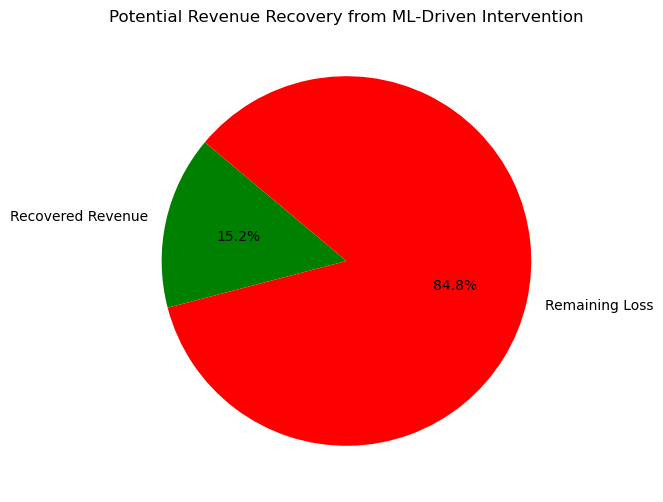

Total Loss: $4641942.67
Recovered: $704680.97
Remaining Loss: $3937261.7


In [33]:
# Visualizing business impact in a simple, executive-friendly way

total_loss = df[df['is_canceled'] == 1]['adr'].sum()
recovered = recovered_revenue
remaining_loss = total_loss - recovered

labels = ['Recovered Revenue', 'Remaining Loss']
values = [recovered, remaining_loss]
colors = ['green', 'red']

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Potential Revenue Recovery from ML-Driven Intervention')
plt.show()

print(f"Total Loss: ${round(total_loss,2)}")
print(f"Recovered: ${round(recovered,2)}")
print(f"Remaining Loss: ${round(remaining_loss,2)}")

<h3>Estimated Business Impact</h3>

<p>
If the hotel uses this model to identify <b>high-risk bookings</b> and applies targeted actions such as 
<b>stricter deposit policies</b> or <b>added cancellation friction</b>, it could recover approximately 
<span style="color:green; font-weight:bold;">$704,680.97</span> in lost revenue.
</p>

<p>
This means the business can reduce avoidable cancellations, improve revenue stability, and make booking forecasts more reliable for shareholders.
</p>

<h3>Action Plan → Business Impact</h3>

<p>
If the hotel <b>requires non-refundable or partial deposits for high-risk bookings</b> 
(specifically customers with long lead times and from Online TA / Groups segments),
then the model indicates it can prevent a portion of cancellations and recover approximately 
<span style="color:green; font-weight:bold;">$704,680.97</span> in lost revenue.
</p>

<p>
<b>Action:</b> Apply stricter deposit rules only to bookings flagged as high-risk by the model.<br>
<b>Result:</b> Fewer cancellations → more confirmed stays → higher realized revenue.
</p>